# Stratégie Value - Concentration sur asset class : rates/credit

## Préambules

### Préambule I - Rappel académique

La stratégie développée dans ce notebook s’inscrit dans la littérature extensive sur les primes de risque systématiques, en particulier sur la prime value telle que formalisée dans les modèles factoriels de Fama and French 1992. Dans cette approche, la value est définie de manière intrinsèquement cross-sectionnelle, en comparant des actifs entre eux à une date donnée afin d’identifier ceux qui offrent une valorisation relativement attractive. La construction de notre signal value par standardisation cross-sectionnelle au sein de buckets homogènes (rates et crédit) reproduit cette logique fondamentale : il ne s’agit pas d’évaluer si un actif est “bon marché” en absolu, mais s’il l’est relativement aux autres opportunités disponibles dans l’univers d’investissement. Cette approche est cohérente avec la construction des facteurs HML, qui reposent sur des portefeuilles long/short basés sur des classements relatifs.

Par ailleurs, la stratégie implémentée est directement alignée avec les travaux de Value and Momentum Everywhere, qui montrent que les primes value et momentum sont présentes de manière robuste à travers différentes classes d’actifs et reposent sur une structure factorielle commune. En particulier, notre utilisation d’un signal value uniforme (yields, spreads, proxies de carry) appliqué à des actifs hétérogènes, puis normalisé cross-sectionnellement, correspond à leur méthodologie visant à capturer une notion unifiée de “cheapness” à l’échelle globale. Le fait de combiner value et momentum dans une approche 50/50 reproduit également l’un de leurs résultats centraux, à savoir l’amélioration significative du profil de Sharpe liée à la corrélation négative entre ces deux facteurs .

La dimension de mean reversion de la stratégie value peut être interprétée à la lumière des travaux comportementaux, notamment Lakonishok Shleifer Vishny 1994. Ces auteurs montrent que les investisseurs ont tendance à extrapoler excessivement les performances passées, conduisant à une surévaluation des actifs “glamour” et à une sous-évaluation des actifs délaissés. Dans ce cadre, une stratégie value cross-sectionnelle exploite des écarts relatifs de valorisation créés par ces biais, et parie sur leur correction future. La mean reversion n’est donc pas nécessairement temporelle au sens strict, mais s’exprime à travers la convergence des valorisations relatives entre actifs.

En complément, l’introduction d’un signal value time-series basé sur une standardisation sur 5 ans s’inspire des travaux de De Bondt and Thaler 1985, qui documentent des phénomènes de retournement à long terme liés à des sur-réactions passées du marché. Cette composante permet de capturer une dimension différente de la value, fondée sur la déviation d’un actif par rapport à sa propre histoire, plutôt que par rapport aux autres actifs. La combinaison des approches cross-sectionnelle et temporelle permet ainsi de capter à la fois des inefficiences relatives et des dynamiques de retour à la moyenne propres à chaque actif.

Enfin, la structuration du portefeuille, notamment via une approche long/short et la standardisation des signaux, s’inscrit dans le cadre plus général de l’Arbitrage Pricing Theory, selon lequel les rendements des actifs peuvent être expliqués par leur exposition à des facteurs systématiques. La stratégie développée peut ainsi être interprétée comme une extraction empirique du facteur value dans un univers multi-actifs, où les signaux sont construits de manière cohérente et comparable. En ce sens, elle constitue une implémentation opérationnelle d’un facteur value global, en ligne avec les approches modernes de gestion factorielle utilisées dans l’industrie.

### Préambule II - Erreurs commises en amont de cette version

#### A - Proxy global :

Nous avons essayé d'implémenter une stratégie value cependant, nous avions introduit un proxy global (indicateur d'inflation anticipée à 10 ans pour l'Europe), c'est une erreur. La littérature académique montre clairement que la performance des stratégies value cross-sectionnelles repose fondamentalement sur l’existence et la persistance d’une dispersion relative entre actifs, et non sur leur niveau absolu. 

Dans des travaux comme ceux d’Asness, Moskowitz et Pedersen, la construction du facteur value consiste à classer des actifs entre eux à une date donnée à partir de signaux définis localement, puis à exploiter les écarts de valorisation relatifs qui en résultent. Cette logique implique que chaque signal doit refléter les conditions économiques propres à l’actif considéré, car c’est précisément l’hétérogénéité entre ces conditions (politiques monétaires distinctes, anticipations d’inflation différentes, primes de risque spécifiques) qui génère la dispersion exploitable. 

Lorsque l’on remplace une composante locale essentielle, comme l’inflation anticipée, par un proxy global commun à plusieurs pays, on impose artificiellement une homogénéité qui n’existe pas dans les données économiques sous-jacentes. Cela a pour effet de comprimer la variance cross-sectionnelle du signal, voire d’introduire des classements erronés entre actifs, ce qui détériore directement la capacité de la stratégie à identifier des situations de sur- ou sous-valorisation relative. Autrement dit, en effaçant une source réelle de dispersion, on affaiblit le mécanisme même par lequel la value cross-sectionnelle génère ses performances, qui repose sur la convergence future de prix initialement différenciés à tort entre actifs comparables.

#### B - Signal value - time series :

Même si nous avons gardé ce signal value dans notre recherche, nous avons cependant diminué son importance. En effet, lors de première version c'était notre signal principal, mal défini car associé au proxy global ne nous permettant pas d'avoir de bonnes performances. De plus nous n'avions pas couplé notre stratégie value à d'autres stratégies.

### Préambule III - Etapes et résultats avant d'arriver à notre version finale :

1ere version : Proxy global + signal value (time series)

|Indicateur | Valeur |
| :--- | :----: | 
|Annual return| 0.57%| 
|   Annual vol |   7.2%   | 
|Sharpe |   0.079    |
| Max drawdown |  -37.5% |  

**2e version** : Reprise des données *(présentées comme ci-après)* et traitement afin d'avoir un signal value cross-sectionnel ainsi que comparaison avec momentum

|                                 |   n_months |   ann_return |   ann_vol |   sharpe |   max_drawdown |   hit_ratio |
:--------------------------------|-----------:|-------------:|----------:|---------:|---------------:|------------:|
| ('Value', 'through_2020')       |        263 |    0.0232176 | 0.0573151 | 0.405086 |     -0.206883  |    0.581749 |
| ('Momentum', 'through_2020')    |        265 |    0.0159052 | 0.0643206 | 0.24728  |     -0.220225  |    0.562264 |
| ('Combo_50_50', 'through_2020') |        263 |    0.0207283 | 0.0264554 | 0.783521 |     -0.0537175 |    0.596958 |
| ('Value', '2021_2026')          |         62 |    0.0324403 | 0.0278586 | 1.16446  |     -0.0281661 |    0.66129  |
| ('Momentum', '2021_2026')       |         62 |    0.0258005 | 0.0344296 | 0.749369 |     -0.0285995 |    0.612903 |
| ('Combo_50_50', '2021_2026')    |         62 |    0.0292923 | 0.0251176 | 1.16621  |     -0.0179436 |    0.66129  |

**3e version** : cross-sectional value signal is seperated between rates and credit

|                                 |   n_months |   ann_return |   ann_vol |   sharpe |   max_drawdown |   hit_ratio |
|:--------------------------------|-----------:|-------------:|----------:|---------:|---------------:|------------:|
| ('Value', 'through_2020')       |        263 |    0.0176972 | 0.0331869 | 0.53326  |     -0.106328  |    0.581749 |
| ('Momentum', 'through_2020')    |        265 |    0.0116428 | 0.041905  | 0.277838 |     -0.148002  |    0.543396 |
| ('Combo_50_50', 'through_2020') |        263 |    0.0149872 | 0.0222569 | 0.673374 |     -0.0501417 |    0.574144 |
| ('Value', '2021_2026')          |         62 |    0.0237504 | 0.0196826 | 1.20667  |     -0.0229761 |    0.629032 |
| ('Momentum', '2021_2026')       |         62 |    0.0221636 | 0.0328398 | 0.674901 |     -0.0342983 |    0.596774 |
| ('Combo_50_50', '2021_2026')    |         62 |    0.0230951 | 0.0213912 | 1.07966  |     -0.0136924 |    0.548387 |

We see that Sharpe improved (even if we lose a bit of return, volatility droped a lot, and drawdown too)

**4e version** : on intègre une version time series et de fait mean reversion du signal value

|                                     |   n_months |   ann_return |   ann_vol |    sharpe |   max_drawdown |   hit_ratio |
|:------------------------------------|-----------:|-------------:|----------:|----------:|---------------:|------------:|
| ('Value_CS_bucket', 'through_2020') |        263 |   0.0176972  | 0.0331869 |  0.53326  |     -0.106328  |    0.581749 |
| ('Value_TS_5Y', 'through_2020')     |        241 |   0.0180946  | 0.072721  |  0.248821 |     -0.32373   |    0.53112  |
| ('Momentum', 'through_2020')        |        265 |   0.0116428  | 0.041905  |  0.277838 |     -0.148002  |    0.543396 |
| ('Combo_CS_50_50', 'through_2020')  |        263 |   0.0149872  | 0.0222569 |  0.673374 |     -0.0501417 |    0.574144 |
| ('Combo_TS_50_50', 'through_2020')  |        241 |   0.0180944  | 0.0279651 |  0.647036 |     -0.114527  |    0.609959 |
| ('Value_CS_bucket', '2021_2026')    |         62 |   0.0237504  | 0.0196826 |  1.20667  |     -0.0229761 |    0.629032 |
| ('Value_TS_5Y', '2021_2026')        |         62 |  -0.0088318  | 0.0290891 | -0.303612 |     -0.159257  |    0.387097 |
| ('Momentum', '2021_2026')           |         62 |   0.0221636  | 0.0328398 |  0.674901 |     -0.0342983 |    0.596774 |
| ('Combo_CS_50_50', '2021_2026')     |         62 |   0.0230951  | 0.0213912 |  1.07966  |     -0.0136924 |    0.548387 |
| ('Combo_TS_50_50', '2021_2026')     |         62 |   0.00678292 | 0.0224291 |  0.302417 |     -0.0534484 |    0.516129 |

Dans la version finale que nous implémentons ici, nous rajoutons le fait que la stratégie value peut être composée d'un signal value composite : 50% mean reversion, 50% cross sectional.




# Backtest fixed income — value CS par bucket, value temporelle, value globale 50/50, puis combo avec momentum

Ce notebook construit une stratégie **sans filtre macro**, avec quatre briques de signal :

1. une **value cross-sectionnelle par bucket** (`Rates` séparément de `Credit`) ;
2. une **value temporelle** fondée sur un z-score roulant de 5 ans par actif ;
3. une **value globale** définie comme **50 % cross-sectionnelle + 50 % temporelle** ;
4. un **momentum 12-1** standardisé par bucket.

Le but est de comparer :

- une stratégie **value cross-sectionnelle pure** ;
- une stratégie **value temporelle pure** ;
- une stratégie **value globale 50/50 (CS + TS)** ;
- une stratégie **momentum** ;
- puis trois combos **Value + Momentum** :
  - `Combo_CS_50_50`
  - `Combo_TS_50_50`
  - `Combo_Global_50_50`

Le tout est ensuite comparé **jusqu'à fin 2020** puis sur **2021–2026**.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RETURNS_FILE = "/Users/tristanlenest/Downloads/01_universe_returns_clean.xlsx"
SIGNALS_FILE = "/Users/tristanlenest/Downloads/02_signals_clean.xlsx"
MACRO_FILE   = "/Users/tristanlenest/Downloads/03_macro_clean.xlsx"  # chargé uniquement pour référence, non utilisé
META_FILE    = "/Users/tristanlenest/Downloads/04_asset_metadata.xlsx"


In [2]:

# Chargement des données
returns = pd.read_excel(RETURNS_FILE)
signals = pd.read_excel(SIGNALS_FILE)
macro   = pd.read_excel(MACRO_FILE)
meta    = pd.read_excel(META_FILE)

for df in [returns, signals, macro]:
    df["Dates"] = pd.to_datetime(df["Dates"])

returns = returns.set_index("Dates").sort_index()
signals = signals.set_index("Dates").sort_index()
macro   = macro.set_index("Dates").sort_index()

display(meta)
print("Période returns :", returns.index.min().date(), "->", returns.index.max().date())
print("Période signals :", signals.index.min().date(), "->", signals.index.max().date())
print("Nb d'actifs     :", len(meta))


,asset,bucket,subgroup,label,level_col,breakeven_col,carry_col
0,BCEY4T Index,Rates,Anglophone,Canada,GCAN10YR Index,NaN,GCAN10YR Index
1,BCEG9T Index,Rates,Core Europe,Germany,GDBR10 Index,DEGGBE10 Index,GDBR10 Index
2,H12823GB Index,Rates,Anglophone,UK,GUKG10 Index,UKGGBE10 Index,GUKG10 Index
3,SPFIJ1BP Index,Rates,Defensive/APAC,Japan,GJGB10 Index,NaN,GJGB10 Index
4,H01661US Index,Rates,Anglophone,US,USGG10YR Index,USGGBE10 Index,USGG10YR Index
5,I01682AU Index,Rates,Anglophone,Australia,GACGB10 Index,NaN,GACGB10 Index
6,H28054US Index,Rates,Defensive/APAC,Switzerland,GTCHF10YR Govt,NaN,GTCHF10YR Govt
7,BCEW9T Index,Rates,Core Europe,France,GFRN 10 Index,FRGGBE10 Index,GFRN 10 Index
8,BCEF9T Index,Rates,Core Europe,Sweden,GSGB10YR Index,SKGGBE10 Index,GSGB10YR Index
9,BCEI9T Index,Rates,Peripheral Europe,Italy,GBTPGR10 Index,GILGBE10 Index,GBTPGR10 Index


Période returns : 1990-01-31 -> 2026-02-27
Période signals : 1990-01-31 -> 2026-02-27
Nb d'actifs     : 15



## I) Signal value - cross sectional

On définit un **proxy de cheapness** par actif :

- si on a `level_col` et `breakeven_col` :  
  **value raw = nominal yield − breakeven = real yield**
- sinon si on a `level_col` :  
  **value raw = nominal yield**
- sinon :  
  **value raw = carry / OAS / spread proxy**

Interprétation :
- **plus la variable est élevée, plus l'actif est cheap** ;
- le portefeuille **achète les actifs les plus cheap** et **vend les plus rich**.

Ensuite, on standardise **en cross-section à chaque date** avec un z-score.


In [3]:

def pick_value_series(row: pd.Series, signal_df: pd.DataFrame) -> pd.Series:
    level_col = row.get("level_col")
    be_col    = row.get("breakeven_col")
    carry_col = row.get("carry_col")

    has_level = pd.notna(level_col) and level_col in signal_df.columns
    has_be    = pd.notna(be_col) and be_col in signal_df.columns
    has_carry = pd.notna(carry_col) and carry_col in signal_df.columns

    if has_level and has_be:
        # Proxy de "cheapness" prioritaire : real yield
        return signal_df[level_col] - signal_df[be_col]
    elif has_level:
        # Sinon nominal yield
        return signal_df[level_col]
    elif has_carry:
        # Sinon spread / OAS / carry proxy
        return signal_df[carry_col]
    else:
        return pd.Series(index=signal_df.index, dtype=float)

value_raw = pd.DataFrame(index=signals.index)

for _, row in meta.iterrows():
    value_raw[row["asset"]] = pick_value_series(row, signals)

value_raw.head()


,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
1990-01-31,9.940,NaN,NaN,6.76,NaN,12.71,NaN,NaN,NaN,NaN,NaN,0.95,NaN,NaN,NaN
1990-02-28,10.644,NaN,NaN,7.13,NaN,13.30,NaN,NaN,NaN,NaN,NaN,0.92,NaN,NaN,NaN
1990-03-30,11.137,NaN,NaN,7.45,NaN,13.45,NaN,NaN,NaN,NaN,NaN,0.91,NaN,NaN,NaN
1990-04-30,11.598,NaN,NaN,6.86,NaN,13.80,NaN,NaN,NaN,NaN,NaN,0.91,NaN,NaN,NaN
1990-05-31,10.805,NaN,NaN,6.34,NaN,13.50,NaN,NaN,NaN,NaN,NaN,0.87,NaN,NaN,NaN


### B - Standardisation du signal value cross-sectionnel par bucket

Dans cette version, la standardisation n'est plus faite sur tout l'univers en une seule fois. Les z-scores sont calculés **séparément dans `Rates` et dans `Credit`** à chaque date. Cela évite de comparer directement un real yield souverain à un OAS crédit au moment de la normalisation du signal.

In [4]:
asset_to_bucket = meta.set_index("asset")["bucket"].to_dict()


def bucket_cross_sectional_zscore(df: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    """Standardise les signaux date par date, séparément dans chaque bucket (Rates vs Credit)."""
    asset_to_bucket = meta.set_index("asset")["bucket"].to_dict()
    bucket_series = pd.Series({c: asset_to_bucket.get(c) for c in df.columns})

    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)

    for bucket in bucket_series.dropna().unique():
        cols = bucket_series.index[bucket_series == bucket].tolist()
        sub = df[cols]

        def _z(row: pd.Series) -> pd.Series:
            valid = row.dropna()
            if len(valid) < 2:
                return row * np.nan
            sigma = valid.std(ddof=0)
            if sigma == 0 or np.isnan(sigma):
                return row * np.nan
            return (row - valid.mean()) / sigma

        out[cols] = sub.apply(_z, axis=1)

    return out


# Lag de 1 mois pour éviter toute anticipation
value_cs = bucket_cross_sectional_zscore(value_raw, meta).shift(1)

value_cs.tail()

,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
2025-10-31,1.091585,-0.868372,-0.318628,-0.267283,-0.150783,2.078291,-1.566839,-0.210627,-0.829420,-0.115019,1.157094,-0.635229,1.730939,-0.552566,-0.543144
2025-11-28,1.082702,-0.884342,-0.352130,-0.188225,-0.107324,2.114432,-1.562579,-0.187348,-0.817553,-0.201372,1.103738,-0.637364,1.730864,-0.548286,-0.545215
2025-12-31,1.036710,-0.865380,-0.406031,-0.106529,-0.135367,2.206392,-1.529589,-0.271683,-0.732059,-0.246867,1.050402,-0.634614,1.730972,-0.548634,-0.547724
2026-01-30,1.104148,-0.834952,-0.469537,-0.035273,-0.155967,2.194142,-1.526439,-0.242819,-0.782940,-0.233651,0.983288,-0.635647,1.730932,-0.546457,-0.548829
2026-02-27,1.101113,-0.873058,-0.548168,0.167936,-0.118666,2.213877,-1.470131,-0.349517,-0.700360,-0.359931,0.936906,-0.636659,1.730893,-0.546883,-0.547351


## II) Signal value temporel (z-score roulant 5 ans) et signal value global

On ajoute ici une seconde définition de la value. Au lieu de comparer les actifs entre eux à une date donnée, on compare **chaque actif à sa propre histoire** sur une fenêtre roulante de **60 mois**.

Pour chaque actif $i$, on calcule :

$
z^{TS}_{i,t} = \frac{x_{i,t} - \mu_{i,t-60:t-1}}{\sigma_{i,t-60:t-1}}
$

où $x_{i,t}$ est le signal value brut (real yield, nominal yield ou spread). Un z-score positif signifie que l'actif est **plus cheap qu'habituellement** relativement à sa propre histoire récente.

On construit ensuite un **signal value global** :

$
z^{Value,Global}_{i,t} = 0.5 \times z^{CS}_{i,t} + 0.5 \times z^{TS}_{i,t}
$

L'objectif est de combiner :
- une logique **relative entre actifs** (cross-sectionnelle) ;
- une logique **historique propre à chaque actif** (temporelle).


In [5]:
def rolling_timeseries_zscore(df: pd.DataFrame, window: int = 60, min_periods: int = 36) -> pd.DataFrame:
    """Z-score temporel par actif sur fenêtre roulante, décalé d'un mois pour éviter tout look-ahead."""
    rolling_mean = df.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = df.rolling(window=window, min_periods=min_periods).std(ddof=0)
    z = (df - rolling_mean) / rolling_std.replace(0, np.nan)
    return z.shift(1)

value_ts = rolling_timeseries_zscore(value_raw, window=60, min_periods=36)

# Signal value global : 50% cross-sectionnel bucketisé + 50% temporel
value_global = 0.5 * value_cs + 0.5 * value_ts

display(value_ts.tail())
display(value_global.tail())


,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
2025-10-31,0.541562,1.318272,1.340354,2.161566,0.723816,0.847574,-0.479513,1.624652,1.219236,0.594888,0.701352,-1.363302,-0.547313,-1.164400,-1.114908
2025-11-28,0.445499,1.184713,1.234617,2.089543,0.682838,0.823486,-0.661013,1.528084,1.121345,0.425832,0.587591,-1.148266,-0.598307,-0.956955,-1.093002
2025-12-31,0.452020,1.192527,1.184025,2.237622,0.670357,0.991185,-0.609164,1.429237,1.204455,0.397430,0.578687,-1.034179,-0.700432,-1.081897,-1.256654
2026-01-30,0.772562,1.321702,1.195939,2.538241,0.761210,1.171419,-0.402974,1.566080,1.245838,0.536194,0.654650,-1.097323,-0.810988,-1.090184,-1.336818
2026-02-27,0.733535,1.135012,1.048872,2.664950,0.712700,1.209031,-0.580610,1.318429,1.205669,0.294568,0.565995,-1.276981,-0.775034,-1.071716,-1.279646


,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
2025-10-31,0.816574,0.224950,0.510863,0.947142,0.286516,1.462932,-1.023176,0.707013,0.194908,0.239934,0.929223,-0.999265,0.591813,-0.858483,-0.829026
2025-11-28,0.764101,0.150185,0.441243,0.950659,0.287757,1.468959,-1.111796,0.670368,0.151896,0.112230,0.845664,-0.892815,0.566278,-0.752621,-0.819108
2025-12-31,0.744365,0.163573,0.388997,1.065547,0.267495,1.598789,-1.069377,0.578777,0.236198,0.075282,0.814544,-0.834397,0.515270,-0.815266,-0.902189
2026-01-30,0.938355,0.243375,0.363201,1.251484,0.302622,1.682780,-0.964707,0.661630,0.231449,0.151272,0.818969,-0.866485,0.459972,-0.818320,-0.942823
2026-02-27,0.917324,0.130977,0.250352,1.416443,0.297017,1.711454,-1.025371,0.484456,0.252654,-0.032681,0.751451,-0.956820,0.477930,-0.809299,-0.913498


## III) Signal momentum

Momentum cross-sectionnel standard **12-1** :

- cumul des rendements mensuels de **t-12 à t-2** ;
- exclusion de **t-1** ;
- standardisation **par bucket** à chaque date (`Rates` séparément de `Credit`) ;
- lag implicite cohérent avec la construction du signal.

On garde donc une comparaison relative entre actifs pour le momentum, alors que l'on compare ensuite cette logique avec une value temporelle propre à chaque actif.

In [6]:
# Momentum 12-1 : produit des rendements de t-12 à t-2
momentum_raw = (1 + returns.shift(1)).rolling(11).apply(np.prod, raw=True) - 1
momentum_signal = bucket_cross_sectional_zscore(momentum_raw, meta)

momentum_signal.tail()

,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
2025-10-31,0.729867,-0.697037,0.278101,-2.317424,0.684363,0.902512,0.923430,-1.158813,-0.524960,0.385713,0.794248,0.167101,-1.397895,1.409292,-0.178498
2025-11-28,0.854423,-1.039018,0.536457,-2.022664,0.854509,0.776047,0.844633,-1.247873,-0.607483,0.146595,0.904373,0.113590,-1.446088,1.376232,-0.043733
2025-12-31,1.616139,-0.774329,0.646317,-2.350465,0.678859,0.114478,0.677987,-0.842258,-0.179658,0.413283,-0.000356,0.975325,-1.259404,0.985334,-0.701255
2026-01-30,1.564322,-0.629862,0.793140,-2.352972,0.160036,0.078963,0.833642,-0.962382,-0.163201,0.540339,0.137976,0.951270,-1.405544,0.940001,-0.485727
2026-02-27,0.757112,-0.605289,0.803299,-2.479601,-0.088878,-0.220328,1.317277,-0.759437,-0.061572,0.677539,0.659877,0.320115,-1.258116,1.437181,-0.499179


## IV) Fonctions de backtest

On implémente ici une version simple et robuste :

- tri cross-sectionnel chaque mois ;
- portefeuille **long top tercile / short bottom tercile** ;
- pondération **égalitaire** dans chaque jambe ;
- pas de leverage, pas de target de volatilité, pas de coût de transaction.

On calcule ensuite trois types de combos avec le momentum :

$
r^{combo}_t = 0.5 \, r^{value}_t + 0.5 \, r^{mom}_t
$

où $r^{value}_t$ peut être :
- la value **cross-sectionnelle** ;
- la value **temporelle** ;
- la value **globale 50/50 (CS + TS)**.


In [ ]:

def long_short_tercile_returns(signal: pd.DataFrame, returns: pd.DataFrame, min_assets: int = 6) -> pd.Series:
    out = []

    for dt in returns.index:
        s = signal.loc[dt].dropna()
        r = returns.loc[dt].dropna()

        common = s.index.intersection(r.index)
        s = s.loc[common]
        r = r.loc[common]

        if len(common) < min_assets:
            out.append(np.nan)
            continue

        ranks = s.rank(method="first")
        n = len(s)

        long_idx  = s.index[ranks > 2 * n / 3]
        short_idx = s.index[ranks <= n / 3]

        if len(long_idx) == 0 or len(short_idx) == 0:
            out.append(np.nan)
            continue

        ret = r.loc[long_idx].mean() - r.loc[short_idx].mean()
        out.append(ret)

    return pd.Series(out, index=returns.index, name="strategy_return")

# =========================
# STATISTIQUES
# =========================
def ann_return(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) == 0:
        return np.nan
    return (1 + x).prod() ** (12 / len(x)) - 1


def ann_vol(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1) * np.sqrt(12)


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    r = ann_return(monthly_returns)
    v = ann_vol(monthly_returns)
    if pd.isna(r) or pd.isna(v) or v == 0:
        return np.nan
    return r / v


def max_drawdown(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) == 0:
        return np.nan
    nav = (1 + x).cumprod()
    dd = nav / nav.cummax() - 1
    return dd.min()


def summary_stats(monthly_returns: pd.Series) -> pd.Series:
    x = monthly_returns.dropna()
    return pd.Series({
        "n_months": len(x),
        "ann_return": ann_return(x),
        "ann_vol": ann_vol(x),
        "sharpe": sharpe_ratio(x),
        "max_drawdown": max_drawdown(x),
        "hit_ratio": (x > 0).mean() if len(x) else np.nan,
    })


def split_period_stats(series_dict: dict, split_date: str = "2020-12-31") -> pd.DataFrame:
    split_date = pd.Timestamp(split_date)
    rows = []

    for name, s in series_dict.items():
        windows = {
            "full_sample": s,
            "through_2020": s.loc[s.index <= split_date],
            "2021_2026": s.loc[s.index > split_date],
        }
        for window_name, window_s in windows.items():
            stats = summary_stats(window_s)
            stats["strategy"] = name
            stats["window"] = window_name
            rows.append(stats)

    out = pd.DataFrame(rows).set_index(["strategy", "window"])
    return out[["n_months", "ann_return", "ann_vol", "sharpe", "max_drawdown", "hit_ratio"]]


In [ ]:
# Backtests
value_cs_ret     = long_short_tercile_returns(value_cs, returns) # Return : 100% Value CS
value_ts_ret     = long_short_tercile_returns(value_ts, returns) # Return : 100% Value TS
value_global_ret = long_short_tercile_returns(value_global, returns) # Return : 50% Value CS + 50% Value TS = Value Global
mom_ret          = long_short_tercile_returns(momentum_signal, returns) # Return : 100% Momentum

combo_cs_ret     = 0.5 * value_cs_ret + 0.5 * mom_ret
combo_ts_ret     = 0.5 * value_ts_ret + 0.5 * mom_ret
combo_global_ret = 0.5 * value_global_ret + 0.5 * mom_ret #Strat : 50% Value Gloabl + 50% Momentum

strategies = {
    "Value_CS_bucket": value_cs_ret,
    "Value_TS_5Y": value_ts_ret,
    "Value_Global_50_50": value_global_ret,
    "Momentum": mom_ret,
    "Combo_CS_50_50": combo_cs_ret,
    "Combo_TS_50_50": combo_ts_ret,
    "Combo_Global_50_50": combo_global_ret,
}

stats = split_period_stats(strategies)
stats.style.format({
    "ann_return": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "hit_ratio": "{:.1%}",
})


In [ ]:
# Vue synthétique uniquement sur les deux fenêtres qu'on veut comparer
comparison = stats.loc[(slice(None), ["through_2020", "2021_2026"]), :].copy()
comparison.style.format({
    "ann_return": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "hit_ratio": "{:.1%}",
})

,,n_months,ann_return,ann_vol,sharpe,max_drawdown,hit_ratio
strategy,window,,,,,,
Value_CS_bucket,through_2020,263.000000,1.77%,3.32%,0.53,-10.63%,58.2%
Value_TS_5Y,through_2020,241.000000,1.81%,7.27%,0.25,-32.37%,53.1%
Value_Global_50_50,through_2020,241.000000,2.42%,6.55%,0.37,-22.60%,56.8%
Momentum,through_2020,265.000000,1.16%,4.19%,0.28,-14.80%,54.3%
Combo_CS_50_50,through_2020,263.000000,1.50%,2.23%,0.67,-5.01%,57.4%
Combo_TS_50_50,through_2020,241.000000,1.81%,2.80%,0.65,-11.45%,61.0%
Combo_Global_50_50,through_2020,241.000000,2.09%,2.56%,0.82,-8.14%,63.5%
Value_CS_bucket,2021_2026,62.000000,2.38%,1.97%,1.21,-2.30%,62.9%
Value_TS_5Y,2021_2026,62.000000,-0.88%,2.91%,-0.30,-15.93%,38.7%


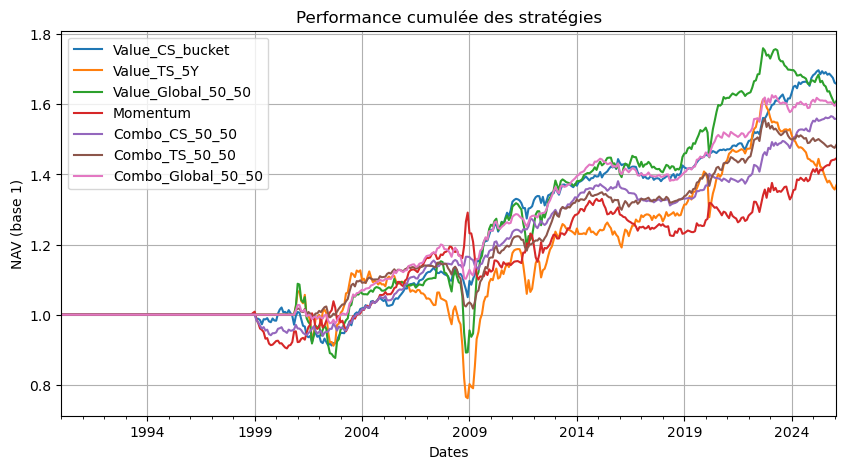

In [10]:
# Courbes de performance cumulée
cum = pd.DataFrame({
    "Value_CS_bucket": (1 + value_cs_ret.fillna(0)).cumprod(),
    "Value_TS_5Y": (1 + value_ts_ret.fillna(0)).cumprod(),
    "Value_Global_50_50": (1 + value_global_ret.fillna(0)).cumprod(),
    "Momentum": (1 + mom_ret.fillna(0)).cumprod(),
    "Combo_CS_50_50": (1 + combo_cs_ret.fillna(0)).cumprod(),
    "Combo_TS_50_50": (1 + combo_ts_ret.fillna(0)).cumprod(),
    "Combo_Global_50_50": (1 + combo_global_ret.fillna(0)).cumprod(),
})

ax = cum.plot(title="Performance cumulée des stratégies")
ax.set_ylabel("NAV (base 1)")
plt.show()


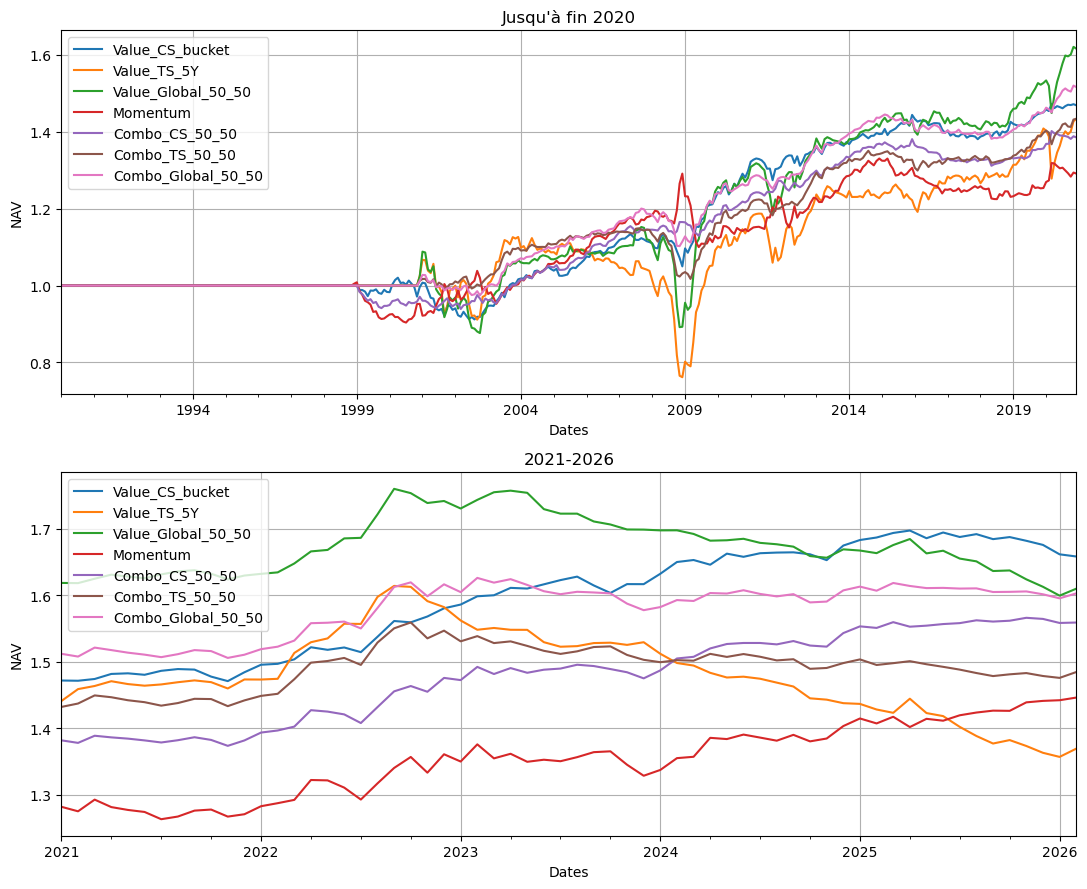

In [11]:
# Zoom : comparaison avant / après 2020
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

cum.loc[cum.index <= "2020-12-31"].plot(ax=axes[0], title="Jusqu'à fin 2020")
axes[0].set_ylabel("NAV")

cum.loc[cum.index > "2020-12-31"].plot(ax=axes[1], title="2021-2026")
axes[1].set_ylabel("NAV")

plt.tight_layout()
plt.show()

In [12]:
# Corrélations avec le momentum
corr_table = pd.DataFrame({
    "Value_CS_vs_Momentum": {
        "corr_full_sample": pd.concat([value_cs_ret, mom_ret], axis=1).corr().iloc[0, 1],
        "corr_through_2020": pd.concat([value_cs_ret.loc[:'2020-12-31'], mom_ret.loc[:'2020-12-31']], axis=1).corr().iloc[0, 1],
        "corr_2021_2026": pd.concat([value_cs_ret.loc['2021-01-01':], mom_ret.loc['2021-01-01':]], axis=1).corr().iloc[0, 1],
    },
    "Value_TS_vs_Momentum": {
        "corr_full_sample": pd.concat([value_ts_ret, mom_ret], axis=1).corr().iloc[0, 1],
        "corr_through_2020": pd.concat([value_ts_ret.loc[:'2020-12-31'], mom_ret.loc[:'2020-12-31']], axis=1).corr().iloc[0, 1],
        "corr_2021_2026": pd.concat([value_ts_ret.loc['2021-01-01':], mom_ret.loc['2021-01-01':]], axis=1).corr().iloc[0, 1],
    },
    "Value_Global_vs_Momentum": {
        "corr_full_sample": pd.concat([value_global_ret, mom_ret], axis=1).corr().iloc[0, 1],
        "corr_through_2020": pd.concat([value_global_ret.loc[:'2020-12-31'], mom_ret.loc[:'2020-12-31']], axis=1).corr().iloc[0, 1],
        "corr_2021_2026": pd.concat([value_global_ret.loc['2021-01-01':], mom_ret.loc['2021-01-01':]], axis=1).corr().iloc[0, 1],
    },
})
corr_table


,Value_CS_vs_Momentum,Value_TS_vs_Momentum,Value_Global_vs_Momentum
corr_full_sample,-0.258226,-0.582645,-0.554704
corr_through_2020,-0.318268,-0.642307,-0.625088
corr_2021_2026,0.281933,0.045860,0.285107


La différence et in et out sample n'existe pas car le CS est pris en t pour t (même si bucketéisé) et Time Series on prend le sample de 5 ans auparavant pour y arriver, donc pas de look ahead, ni de strat qui s'apprend dans le in sample

La stratégie développée dans ce notebook s’inscrit dans la littérature extensive sur les primes de risque systématiques, en particulier sur la prime value telle que formalisée dans les modèles factoriels de Fama and French 1992. Dans cette approche, la value est définie de manière intrinsèquement cross-sectionnelle, en comparant des actifs entre eux à une date donnée afin d’identifier ceux qui offrent une valorisation relativement attractive. La construction de notre signal value par standardisation cross-sectionnelle au sein de buckets homogènes (rates et crédit) reproduit cette logique fondamentale : il ne s’agit pas d’évaluer si un actif est “bon marché” en absolu, mais s’il l’est relativement aux autres opportunités disponibles dans l’univers d’investissement. Cette approche est cohérente avec la construction des facteurs HML, qui reposent sur des portefeuilles long/short basés sur des classements relatifs.

Par ailleurs, la stratégie implémentée est directement alignée avec les travaux de Value and Momentum Everywhere, qui montrent que les primes value et momentum sont présentes de manière robuste à travers différentes classes d’actifs et reposent sur une structure factorielle commune. En particulier, notre utilisation d’un signal value uniforme (yields, spreads, proxies de carry) appliqué à des actifs hétérogènes, puis normalisé cross-sectionnellement, correspond à leur méthodologie visant à capturer une notion unifiée de “cheapness” à l’échelle globale. Le fait de combiner value et momentum dans une approche 50/50 reproduit également l’un de leurs résultats centraux, à savoir l’amélioration significative du profil de Sharpe liée à la corrélation négative entre ces deux facteurs .

La dimension de mean reversion de la stratégie value peut être interprétée à la lumière des travaux comportementaux, notamment Lakonishok Shleifer Vishny 1994. Ces auteurs montrent que les investisseurs ont tendance à extrapoler excessivement les performances passées, conduisant à une surévaluation des actifs “glamour” et à une sous-évaluation des actifs délaissés. Dans ce cadre, une stratégie value cross-sectionnelle exploite des écarts relatifs de valorisation créés par ces biais, et parie sur leur correction future. La mean reversion n’est donc pas nécessairement temporelle au sens strict, mais s’exprime à travers la convergence des valorisations relatives entre actifs.

En complément, l’introduction d’un signal value time-series basé sur une standardisation sur 5 ans s’inspire des travaux de De Bondt and Thaler 1985, qui documentent des phénomènes de retournement à long terme liés à des sur-réactions passées du marché. Cette composante permet de capturer une dimension différente de la value, fondée sur la déviation d’un actif par rapport à sa propre histoire, plutôt que par rapport aux autres actifs. La combinaison des approches cross-sectionnelle et temporelle permet ainsi de capter à la fois des inefficiences relatives et des dynamiques de retour à la moyenne propres à chaque actif.

Enfin, la structuration du portefeuille, notamment via une approche long/short et la standardisation des signaux, s’inscrit dans le cadre plus général de l’Arbitrage Pricing Theory, selon lequel les rendements des actifs peuvent être expliqués par leur exposition à des facteurs systématiques. La stratégie développée peut ainsi être interprétée comme une extraction empirique du facteur value dans un univers multi-actifs, où les signaux sont construits de manière cohérente et comparable. En ce sens, elle constitue une implémentation opérationnelle d’un facteur value global, en ligne avec les approches modernes de gestion factorielle utilisées dans l’industrie.